In [9]:
import pandas as pd
df = pd.read_csv('telecom_data.csv')
print(df)

     Age  Gender  PlanType  MonthlyUsage Churn
0     21  Female   Regular            15    No
1     45  Female   Economy            41    No
2     44  Female   Economy            40    No
3     31  Female   Regular            23   Yes
4     33  Female   Regular            12    No
..   ...     ...       ...           ...   ...
145   19  Female  Advanced             3    No
146   42  Female  Advanced            52    No
147   54  Female     Ultra             7    No
148   20  Female   Economy            57   Yes
149   31  Female  Standard            23   Yes

[150 rows x 5 columns]


In [10]:
df.isnull().sum()

Age             0
Gender          0
PlanType        0
MonthlyUsage    0
Churn           0
dtype: int64

In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   Age           150 non-null    int64 
 1   Gender        150 non-null    object
 2   PlanType      150 non-null    object
 3   MonthlyUsage  150 non-null    int64 
 4   Churn         150 non-null    object
dtypes: int64(2), object(3)
memory usage: 6.0+ KB


In [12]:
df.shape

(150, 5)

In [13]:
df.describe()

,Age,MonthlyUsage
count,150.000000,150.000000
mean,35.193333,33.693333
std,10.841566,15.923031
min,19.000000,3.000000
25%,25.000000,23.000000
50%,35.000000,35.000000
75%,44.000000,50.000000
max,54.000000,59.000000


In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   Age           150 non-null    int64 
 1   Gender        150 non-null    object
 2   PlanType      150 non-null    object
 3   MonthlyUsage  150 non-null    int64 
 4   Churn         150 non-null    object
dtypes: int64(2), object(3)
memory usage: 6.0+ KB


In [15]:
print(df['Gender'].value_counts(normalize=True))

Gender
Female    0.793333
Male      0.206667
Name: proportion, dtype: float64


In [16]:
print(df['Churn'].value_counts(normalize=False))

Churn
No     134
Yes     16
Name: count, dtype: int64


In [17]:
print(df['Churn'].value_counts(normalize=True))

Churn
No     0.893333
Yes    0.106667
Name: proportion, dtype: float64


In [18]:
df.dtypes

Age              int64
Gender          object
PlanType        object
MonthlyUsage     int64
Churn           object
dtype: object

<Axes: >

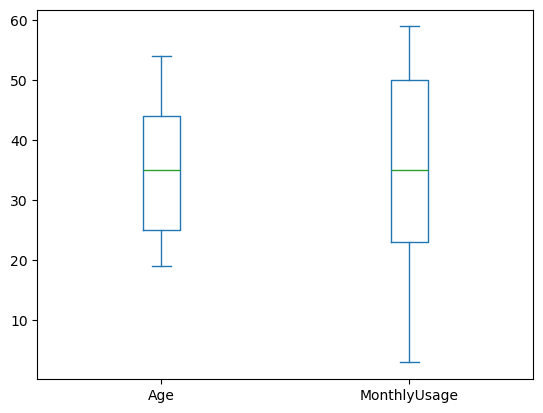

In [19]:
df.plot(kind='box')

In [20]:
fdata = df.drop(columns=['Churn'])
X = fdata
y = df['Churn'].map({'Yes':1,'No':0})

cat = fdata.select_dtypes(include = 'object').columns
num = fdata.select_dtypes(exclude = 'object').columns
print("Categorical Values:",list(cat))
print("Numerical values:",list(num))

Categorical Values: ['Gender', 'PlanType']
Numerical values: ['Age', 'MonthlyUsage']


In [21]:
from sklearn.preprocessing import OneHotEncoder, StandardScaler
X_encoded_gd = pd.get_dummies(
    X,
    columns = cat,
    drop_first = True)
print("gd:",X_encoded_gd.columns.tolist())

gd: ['Age', 'MonthlyUsage', 'Gender_Male', 'PlanType_Economy', 'PlanType_Regular', 'PlanType_Standard', 'PlanType_Ultra']


In [22]:
print(X_encoded_gd['PlanType_Economy'].head(10))

0    False
1     True
2     True
3    False
4    False
5    False
6    False
7    False
8    False
9     True
Name: PlanType_Economy, dtype: bool


In [23]:
ohe = OneHotEncoder(
    drop = 'first',
    sparse_output = False
)
encoded_array = ohe.fit_transform(X[cat])

encoded_df = pd.DataFrame(
    encoded_array,
    columns = ohe.get_feature_names_out(cat)
)
print(encoded_array)
X_encoded_ohe = pd.concat(
    [X[num].reset_index(drop=True),encoded_df.reset_index(drop=True)],
    axis = 1
)
print("One hot encoding columns:",X_encoded_ohe.columns.tolist())

[[0. 0. 1. 0. 0.]
 [0. 1. 0. 0. 0.]
 [0. 1. 0. 0. 0.]
 [0. 0. 1. 0. 0.]
 [0. 0. 1. 0. 0.]
 [0. 0. 1. 0. 0.]
 [0. 0. 0. 0. 1.]
 [1. 0. 0. 0. 1.]
 [0. 0. 0. 0. 0.]
 [1. 1. 0. 0. 0.]
 [0. 1. 0. 0. 0.]
 [0. 0. 1. 0. 0.]
 [0. 0. 0. 1. 0.]
 [0. 0. 0. 1. 0.]
 [1. 0. 0. 0. 0.]
 [0. 0. 1. 0. 0.]
 [0. 0. 0. 0. 0.]
 [0. 0. 1. 0. 0.]
 [1. 0. 0. 0. 1.]
 [0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 1.]
 [0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 1.]
 [1. 0. 1. 0. 0.]
 [1. 0. 0. 1. 0.]
 [0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0.]
 [0. 0. 1. 0. 0.]
 [0. 0. 0. 0. 1.]
 [1. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0.]
 [0. 0. 0. 1. 0.]
 [0. 0. 0. 0. 1.]
 [0. 0. 0. 0. 1.]
 [0. 0. 0. 1. 0.]
 [1. 1. 0. 0. 0.]
 [0. 0. 0. 1. 0.]
 [0. 0. 1. 0. 0.]
 [1. 0. 0. 0. 1.]
 [0. 0. 0. 1. 0.]
 [0. 0. 0. 0. 1.]
 [0. 0. 0. 0. 1.]
 [0. 0. 0. 0. 0.]
 [1. 0. 0. 0. 1.]
 [0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 1.]
 [0. 0. 0. 0. 0.]
 [0. 0. 1. 0. 0.]
 [0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0.]
 [0. 0. 0. 1. 0.]
 [1. 0. 0. 1. 0.]
 [0. 1. 0. 0. 0.]
 [0. 1. 0. 0. 0.]
 [1. 0. 0.

In [24]:
print(encoded_df[['PlanType_Economy']])

     PlanType_Economy
0                 0.0
1                 1.0
2                 1.0
3                 0.0
4                 0.0
..                ...
145               0.0
146               0.0
147               0.0
148               1.0
149               0.0

[150 rows x 1 columns]


In [25]:
scaler = StandardScaler()
X_scaled_gd = X_encoded_gd.copy()
X_scaled_gd[num] = scaler.fit_transform(X_scaled_gd[num])
X_scaled_ohe = X_encoded_gd.copy()
X_scaled_ohe[num] = scaler.fit_transform(X_scaled_ohe[num])
df2 = pd.DataFrame({
    'Age_ohe':X_scaled_ohe[num]['Age'],
    'Age_gd':X_scaled_gd[num]['Age'],
    'MonthlyUsage_ohe':X_scaled_ohe[num]['MonthlyUsage'],
    'MonthlyUsage_gd':X_scaled_gd[num]['MonthlyUsage']
})
print(df2)

      Age_ohe    Age_gd  MonthlyUsage_ohe  MonthlyUsage_gd
0   -1.313545 -1.313545         -1.177914        -1.177914
1    0.907574  0.907574          0.460411         0.460411
2    0.815027  0.815027          0.397399         0.397399
3   -0.388079 -0.388079         -0.673814        -0.673814
4   -0.202986 -0.202986         -1.366951        -1.366951
..        ...       ...               ...              ...
145 -1.498638 -1.498638         -1.934064        -1.934064
146  0.629934  0.629934          1.153549         1.153549
147  1.740493  1.740493         -1.682014        -1.682014
148 -1.406091 -1.406091          1.468612         1.468612
149 -0.388079 -0.388079         -0.673814        -0.673814

[150 rows x 4 columns]


In [34]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled_ohe,
    y,
    test_size = 0.2,
    random_state = 42,
    stratify = y
)
pd.DataFrame({
    "Train":y_train.value_counts(normalize = True),
    "Test":y_test.value_counts(normalize = True)
})


,Train,Test
Churn,,
0,0.891667,0.9
1,0.108333,0.1
